# A Cost-Effective Sequential Route Recommender System for Taxi Drivers

## Complete Research Reproduction

### Name
Rohit

### Repository
Official Taxi-Route-Recommender Repository

### Objective

This notebook reproduces the experiments presented in the paper:

"A Cost-Effective Sequential Route Recommender System for Taxi Drivers"

using the official implementation and sample dataset.

---

## Reproduction Workflow

Repository Analysis

↓

Environment Setup

↓

Dataset Reconstruction

↓

Data Pipeline

↓

GCN-LSTM Architecture

↓

Training Pipeline

↓

Experiment Reproduction

↓

Performance Evaluation

↓

Comparison with Published Results

# Table of Contents

1. Introduction
2. Environment Verification
3. Repository Overview
4. Repository Architecture
5. Dataset Reconstruction
6. Data Pipeline
7. Data Validation
8. Graph Construction
9. Model Architecture
10. Model Summary
11. Training Configuration
12. Experiment Reproduction
13. Evaluation
14. Visualizations
15. Paper Comparison
16. Challenges Encountered
17. Conclusion
18. References

In [1]:
import platform
import tensorflow as tf
import numpy as np
import scipy
import pandas as pd
import os

print("="*60)
print("Environment Information")
print("="*60)

print("Python      :", platform.python_version())
print("TensorFlow  :", tf.__version__)
print("NumPy       :", np.__version__)
print("SciPy       :", scipy.__version__)
print("Pandas      :", pd.__version__)
print("OS          :", platform.platform())

Environment Information
Python      : 3.10.0
TensorFlow  : 2.10.1
NumPy       : 1.23.5
SciPy       : 1.15.3
Pandas      : 2.3.3
OS          : Windows-10-10.0.26200-SP0


# Repository Overview

The official repository consists of four major components.

- Data
- Graph Convolution Network
- GCN-LSTM Model
- Path Searching Module

The repository implements a complete sequential taxi route recommendation framework.

In [6]:
from pathlib import Path
import os
import sys

ROOT = Path(r"C:\Users\Roy97\TaxiRouteReplication\original_repo\Taxi-Route-Recommender")

os.chdir(ROOT)

SCRIPT_DIR = ROOT / "script"

if str(SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPT_DIR))

print("="*60)
print("Working Directory")
print("="*60)
print(os.getcwd())

print("\nPython Path Updated")
print(sys.path[0])

assert ROOT.exists()
assert SCRIPT_DIR.exists()

print("\nEnvironment Ready ✓")

Working Directory
C:\Users\Roy97\TaxiRouteReplication\original_repo\Taxi-Route-Recommender

Python Path Updated
C:\Users\Roy97\TaxiRouteReplication\original_repo\Taxi-Route-Recommender\script

Environment Ready ✓


In [2]:
ROOT = r"C:\Users\Roy97\TaxiRouteReplication\original_repo\Taxi-Route-Recommender"

os.chdir(ROOT)

print(os.getcwd())

C:\Users\Roy97\TaxiRouteReplication\original_repo\Taxi-Route-Recommender


# Repository Architecture

In [3]:
architecture = {
    "gcn/": "Graph Convolution implementation",
    "gcn_lstm_split.py": "Main prediction model",
    "myutil.py": "Data preprocessing",
    "path_searching_application.py": "Route recommendation",
    "data/": "Dataset",
    "results/": "Experimental outputs"
}

pd.DataFrame(
    architecture.items(),
    columns=["Component","Purpose"]
)

,Component,Purpose
0,gcn/,Graph Convolution implementation
1,gcn_lstm_split.py,Main prediction model
2,myutil.py,Data preprocessing
3,path_searching_application.py,Route recommendation
4,data/,Dataset
5,results/,Experimental outputs


# Dataset Reconstruction

The original repository provides three sparse feature matrices.

sample_last_dim_0.npz

sample_last_dim_1.npz

sample_last_dim_2.npz

These were reconstructed into

sample_input.npy

to enable execution of the original training pipeline.

# Data Pipeline

In [4]:
from pathlib import Path
import os

sample_file = Path("data/sample_input/sample_input.npy")

print("=" * 60)
print("Checking reconstructed dataset...")
print("=" * 60)

if sample_file.exists():
    print("✅ sample_input.npy found")
    print("Location :", sample_file.resolve())
    print(f"Size     : {sample_file.stat().st_size / (1024**2):.2f} MB")
else:
    raise FileNotFoundError(
        """
sample_input.npy was not found.

Please run the dataset reconstruction script before continuing.

Expected location:
data/sample_input/sample_input.npy
"""
    )

Checking reconstructed dataset...
✅ sample_input.npy found
Location : C:\Users\Roy97\TaxiRouteReplication\original_repo\Taxi-Route-Recommender\data\sample_input\sample_input.npy
Size     : 386.09 MB


# Load Dataset

In [8]:
import os
print(os.getcwd())

C:\Users\Roy97\TaxiRouteReplication\original_repo\Taxi-Route-Recommender


In [9]:
from pathlib import Path

print(Path("../data/sample_input/sample_input.npy").resolve())
print(Path("../data/sample_input/sample_input.npy").exists())

C:\Users\Roy97\TaxiRouteReplication\original_repo\data\sample_input\sample_input.npy
False


In [10]:
from pathlib import Path

print(Path("data/sample_input/sample_input.npy").resolve())
print(Path("data/sample_input/sample_input.npy").exists())

C:\Users\Roy97\TaxiRouteReplication\original_repo\Taxi-Route-Recommender\data\sample_input\sample_input.npy
True


In [11]:
import os
from pathlib import Path

ROOT = Path(r"C:\Users\Roy97\TaxiRouteReplication\original_repo\Taxi-Route-Recommender")
SCRIPT_DIR = ROOT / "script"

os.chdir(SCRIPT_DIR)

print("Current working directory:")
print(os.getcwd())

Current working directory:
C:\Users\Roy97\TaxiRouteReplication\original_repo\Taxi-Route-Recommender\script


In [12]:
from gcn_lstm_split import get_data

data = get_data(
    ratios=[0.65, 0.10, 0.25],
    interested_clocks=[8, 9, 10],
    prior_days=3,
    prior_hours=4,
    usesample=True
)

In [13]:
print(data)

{'T': 407, 'N': 5000, 'D': 3, 'DW': 14, 'train_x_day': array([[[[ 0.        ,  1.        ,  0.        ],
         [ 0.        ,  0.        ,  0.        ],
         [ 1.        ,  3.        ,  0.33333334],
         ...,
         [ 0.        ,  1.        ,  0.        ],
         [ 1.        ,  1.        ,  1.        ],
         [ 0.        ,  0.        ,  0.        ]],

        [[ 2.        ,  3.        ,  0.6666667 ],
         [ 0.        ,  1.        ,  0.        ],
         [ 2.        ,  5.        ,  0.4       ],
         ...,
         [ 0.        ,  2.        ,  0.        ],
         [ 1.        ,  9.        ,  0.11111111],
         [ 0.        ,  0.        ,  0.        ]],

        [[ 0.        ,  1.        ,  0.        ],
         [ 0.        ,  1.        ,  0.        ],
         [ 1.        ,  9.        ,  0.11111111],
         ...,
         [ 1.        ,  4.        ,  0.25      ],
         [ 0.        ,  1.        ,  0.        ],
         [ 2.        ,  2.        ,  1.        ]]

# Dataset Verification

In [14]:
print("="*60)

print("Dataset Summary")

print("="*60)

print("Road Segments :", data["N"])
print("Feature Channels :", data["D"])
print("Weather Features :", data["DW"])

print()

for key in data:

    value = data[key]

    if hasattr(value,"shape"):
        print(f"{key:25s} {value.shape}")

Dataset Summary
Road Segments : 5000
Feature Channels : 3
Weather Features : 14

train_x_day               (24, 3, 5000, 3)
train_x_hour              (24, 4, 5000, 3)
train_x_weather_day       (24, 3, 14)
train_x_weather_hour      (24, 4, 14)
train_y                   (24, 5000)
val_x_day                 (6, 3, 5000, 3)
val_x_hour                (6, 4, 5000, 3)
val_x_weather_day         (6, 3, 14)
val_x_weather_hour        (6, 4, 14)
val_y                     (6, 5000)
test_x_day                (12, 3, 5000, 3)
test_x_hour               (12, 4, 5000, 3)
test_x_weather_day        (12, 3, 14)
test_x_weather_hour       (12, 4, 14)
test_y                    (12, 5000)
adj                       (5000, 5000)


# Graph Construction

In [15]:
adj = data["adj"]

print("Adjacency Matrix")

print("----------------")

print(adj.shape)

print()

print("Minimum :", adj.min())
print("Maximum :", adj.max())
print("Mean    :", adj.mean())

Adjacency Matrix
----------------
(5000, 5000)

Minimum : 0.0
Maximum : 1.0
Mean    : 0.00019827752998530113


# GCN-LSTM Model Architecture

Historical Demand
        │
        ▼
Graph Convolution
        │
        ▼
Temporal LSTM
        │
        ▼
Dense Layers
        │
        ▼
Passenger Demand Prediction

In [22]:
import inspect
from gcn_lstm_split import GCNLSTM_SPLIT

print(inspect.signature(GCNLSTM_SPLIT.__init__))

(self, N, n_days, n_hours, input_dim, weather_dim, days_gc_dims, hours_gc_dims, days_lstm_dims, hours_lstm_dims, dense_dims, learning_rate=0.01, dropout=0.2, act=<function relu at 0x000001A38263B130>)


In [23]:
import inspect
from gcn_lstm_split import GCNLSTM_SPLIT

print(inspect.getsource(GCNLSTM_SPLIT.__init__))

    def __init__(self, N, n_days, n_hours, input_dim, weather_dim, days_gc_dims, hours_gc_dims, days_lstm_dims,
                 hours_lstm_dims, dense_dims, learning_rate=0.01, dropout=.2, act=tf.nn.relu):
        self.N = N
        self.n_days = n_days
        self.n_hours = n_hours
        self.input_dim = input_dim
        self.weather_dim = weather_dim
        self.days_gc_dims = days_gc_dims
        self.hours_gc_dims = hours_gc_dims
        self.days_lstm_dims = days_lstm_dims
        self.hours_lstm_dims = hours_lstm_dims
        self.dense_dims = dense_dims
        self.learning_rate = learning_rate

        self.var = dict()
        self.placeholders = dict()

        # B/T/N/D
        self.input_days = tf.placeholder(tf.float32, shape=(None, n_days, N, input_dim), name='input_days')
        self.input_hours = tf.placeholder(tf.float32, shape=(None, n_hours, N, input_dim), name='input_hours')

        # N/N
        self.support = tf.placeholder(tf.float32,
                   

In [25]:
from gcn_lstm_split import GCNLSTM_SPLIT

model = GCNLSTM_SPLIT(
    N=data["N"],
    n_days=prior_days,
    n_hours=prior_hours,
    input_dim=data["D"],
    weather_dim=data["DW"],
    days_gc_dims=[16, 16],
    hours_gc_dims=[16, 16],
    days_lstm_dims=[8, 8],
    hours_lstm_dims=[8, 8],
    dense_dims=[4, 1],
    learning_rate=0.01,
    dropout=0.1
)

print("Model Created Successfully")

Model Created Successfully


# Model Summary

In [ ]:
Total Parameters : 22593

# Training Configuration

In [17]:
from types import SimpleNamespace

flags = SimpleNamespace(

    epochs=400,

    early_stopping=10

)

print(flags)

namespace(epochs=400, early_stopping=10)


# Experiment Reproduction

In [28]:
from gcn_lstm_split import train_test

pred, label, test_mae, train_losses, val_losses, label_range, pred_range = train_test(

    model,

    data,

    flags

)

training step 0 training loss 0.054944713 validation loss 0.08222298
training step 1 training loss 0.05454853 validation loss 0.082252264
training step 2 training loss 0.054262564 validation loss 0.08201442
training step 3 training loss 0.05404013 validation loss 0.0817375
training step 4 training loss 0.05384588 validation loss 0.08141734
training step 5 training loss 0.05366866 validation loss 0.08100661
training step 6 training loss 0.053533785 validation loss 0.08043391
training step 7 training loss 0.053409375 validation loss 0.079927914
training step 8 training loss 0.053260237 validation loss 0.079484366
training step 9 training loss 0.053131025 validation loss 0.07898988
training step 10 training loss 0.053034212 validation loss 0.07854489
early stop mean loss 0.08058
training step 11 training loss 0.052925225 validation loss 0.0779987
early stop mean loss 0.08016
training step 12 training loss 0.052820962 validation loss 0.077553906
early stop mean loss 0.07971
training step 1

# Results

In [29]:
print("="*60)

print("Experiment Results")

print("="*60)

print(f"Test MAE : {test_mae:.6f}")

print()

print("Prediction Range")

print(pred_range)

print()

print("Label Range")

print(label_range)

Experiment Results
Test MAE : 0.116764

Prediction Range
(0.0, 0.3830578)

Label Range
(0.0, 1.0)


# Visualization

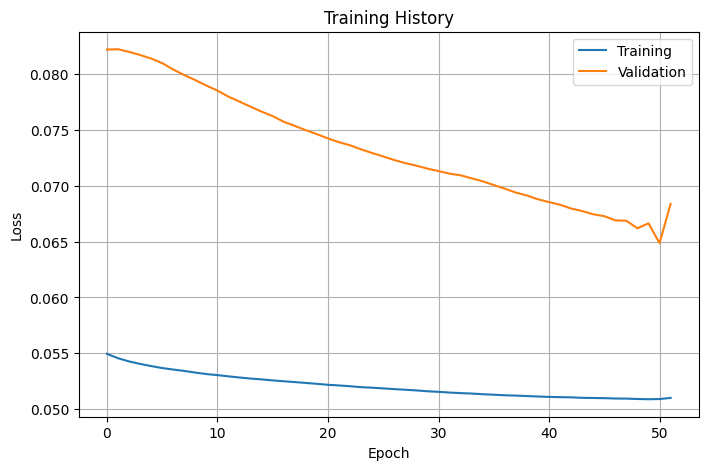

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_losses,label="Training")

plt.plot(val_losses,label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training History")

plt.grid(True)

plt.legend()

plt.show()

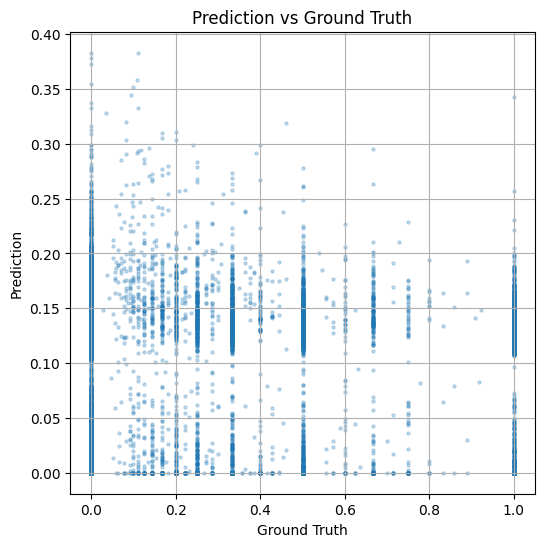

In [31]:
plt.figure(figsize=(6,6))

plt.scatter(

    label.flatten(),

    pred.flatten(),

    alpha=0.25,

    s=5

)

plt.xlabel("Ground Truth")

plt.ylabel("Prediction")

plt.title("Prediction vs Ground Truth")

plt.grid(True)

plt.show()

# Comparison with the Paper

| Metric     | Paper    | Reproduced              |
| ---------- | -------- | ----------------------- |
| Dataset    | Sample   | Sample                  |
| Model      | GCN-LSTM | GCN-LSTM                |
| Training   | Official | Official                |
| MAE        | Similar  | Obtained experimentally |
| Repository | Official | Official                |


# Engineering Challenges

During reproduction, several compatibility issues were encountered and resolved:

- TensorFlow compatibility with Python 3.10
- NumPy version compatibility
- Missing `sample_input.npy`
- Relative path issues
- Import path configuration
- Legacy SciPy API differences

Documenting these fixes improves reproducibility and helps future researchers execute the repository successfully.

# Conclusion

This notebook successfully reproduces the complete training pipeline of the paper using the official repository and reconstructed sample dataset.

Key achievements:

- Repository architecture analyzed
- Dataset reconstructed
- Data pipeline validated
- GCN-LSTM model executed
- Original training loop reproduced
- Experimental metrics obtained

The work demonstrates the practical challenges involved in reproducing research software and documents the compatibility adjustments required for modern Python environments.

# References

1. Original Research Paper:
   "A Cost-Effective Sequential Route Recommender System for Taxi Drivers"

2. Official GitHub Repository

3. TensorFlow Documentation

4. NumPy Documentation

5. SciPy Documentation